# Business Understanding

## Project Domain

Domain: Environmental Science & Data Analytics

Sub-Domain: Air Quality Monitoring & Predictive Systems

Proyek ini berfokus pada pengembangan sistem pemantauan kualitas udara yang memanfaatkan teknologi data dan analitik untuk menilai tingkat polusi di berbagai wilayah. Sistem ini bertujuan untuk memanfaatkan data lingkungan yang tersedia untuk memberikan prediksi dan rekomendasi mengenai kualitas udara, membantu masyarakat dan pemerintah dalam merancang kebijakan yang lebih baik terkait pengelolaan polusi udara.


## Problem Statements

Masalah yang Dihadapi:

1. Polusi Udara yang Tidak Terkendali:
Polusi udara merupakan masalah global yang berdampak pada kesehatan manusia dan lingkungan. Meskipun ada berbagai upaya untuk mengontrol polusi, penilaian kualitas udara secara real-time masih sering kurang akurat dan tidak mudah diakses oleh masyarakat luas.

2. Kurangnya Alat Prediksi yang Akurat:
Banyak daerah yang masih bergantung pada pemantauan manual dan data historis yang terbatas. Hal ini membuatnya sulit untuk memprediksi perubahan kualitas udara secara dini, sehingga pencegahan terhadap dampak buruk polusi udara menjadi terhambat.

3. Dampak Negatif terhadap Kesehatan Masyarakat:
Kualitas udara yang buruk dapat menyebabkan berbagai masalah kesehatan, mulai dari gangguan pernapasan hingga penyakit jantung. Mengingat polusi udara seringkali berasal dari berbagai sumber yang saling terkait, penting untuk memiliki sistem yang dapat memberikan informasi lebih lengkap dan prediktif.

4. Kesulitan dalam Pengelolaan Polusi di Wilayah Padat Penduduk:
Di area perkotaan dan wilayah industri, tingkat polusi dapat meningkat secara signifikan. Mengelola polusi di daerah-daerah ini memerlukan pemahaman yang lebih mendalam mengenai faktor-faktor yang memengaruhi kualitas udara, seperti kepadatan penduduk, aktivitas industri, dan kondisi iklim.

## Goals

Mengembangkan sistem berbasis pembelajaran mesin yang dapat memprediksi kualitas udara berdasarkan data lingkungan (seperti suhu, kelembapan, dan polutan utama seperti PM2.5, NO2, SO2)

## Solution Statements

Pendekatan Solusi yang Diterapkan:

1. Pengembangan Model Pembelajaran Mesin untuk Prediksi Kualitas Udara:
Membangun dan melatih model pembelajaran mesin dengan akurasi (>90%), yang dapat memprediksi tingkat polusi udara di masa depan berdasarkan variabel lingkungan seperti suhu, kelembapan, PM2.5, PM10, NO2, dan faktor-faktor lainnya.

2. Dashboard Interaktif untuk Pemantauan Kualitas Udara:
Mengembangkan aplikasi berbasis web menggunakan platform seperti Streamlit yang memungkinkan pengguna untuk memantau kualitas udara secara real-time, mendapatkan prediksi, dan memperoleh informasi mengenai langkah-langkah mitigasi yang bisa diambil.

3. Optimasi Model (TensorFlow Lite):
Mengonversi model pembelajaran mesin ke dalam format TensorFlow Lite (TFLite), sehingga aplikasi dapat digunakan pada perangkat mobile dengan sumber daya terbatas, memungkinkan pemantauan kualitas udara secara praktis di lapangan.

# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"reizaandriana","key":"523592cf7cf73fd2c83902985daa124e"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d mujtabamatin/air-quality-and-pollution-assessment

Dataset URL: https://www.kaggle.com/datasets/mujtabamatin/air-quality-and-pollution-assessment
License(s): apache-2.0


In [4]:
!mkdir air-quality-and-pollution-assessment
!unzip air-quality-and-pollution-assessment.zip -d air-quality-and-pollution-assessment
!ls air-quality-and-pollution-assessment

Archive:  air-quality-and-pollution-assessment.zip
  inflating: air-quality-and-pollution-assessment/updated_pollution_dataset.csv  
updated_pollution_dataset.csv


## Import Library yang dibutuhkan

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [7]:
data=pd.read_csv('air-quality-and-pollution-assessment/updated_pollution_dataset.csv')
data.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


In [9]:
data.isnull().sum()

,0
Temperature,0
Humidity,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
Proximity_to_Industrial_Areas,0
Population_Density,0
Air Quality,0


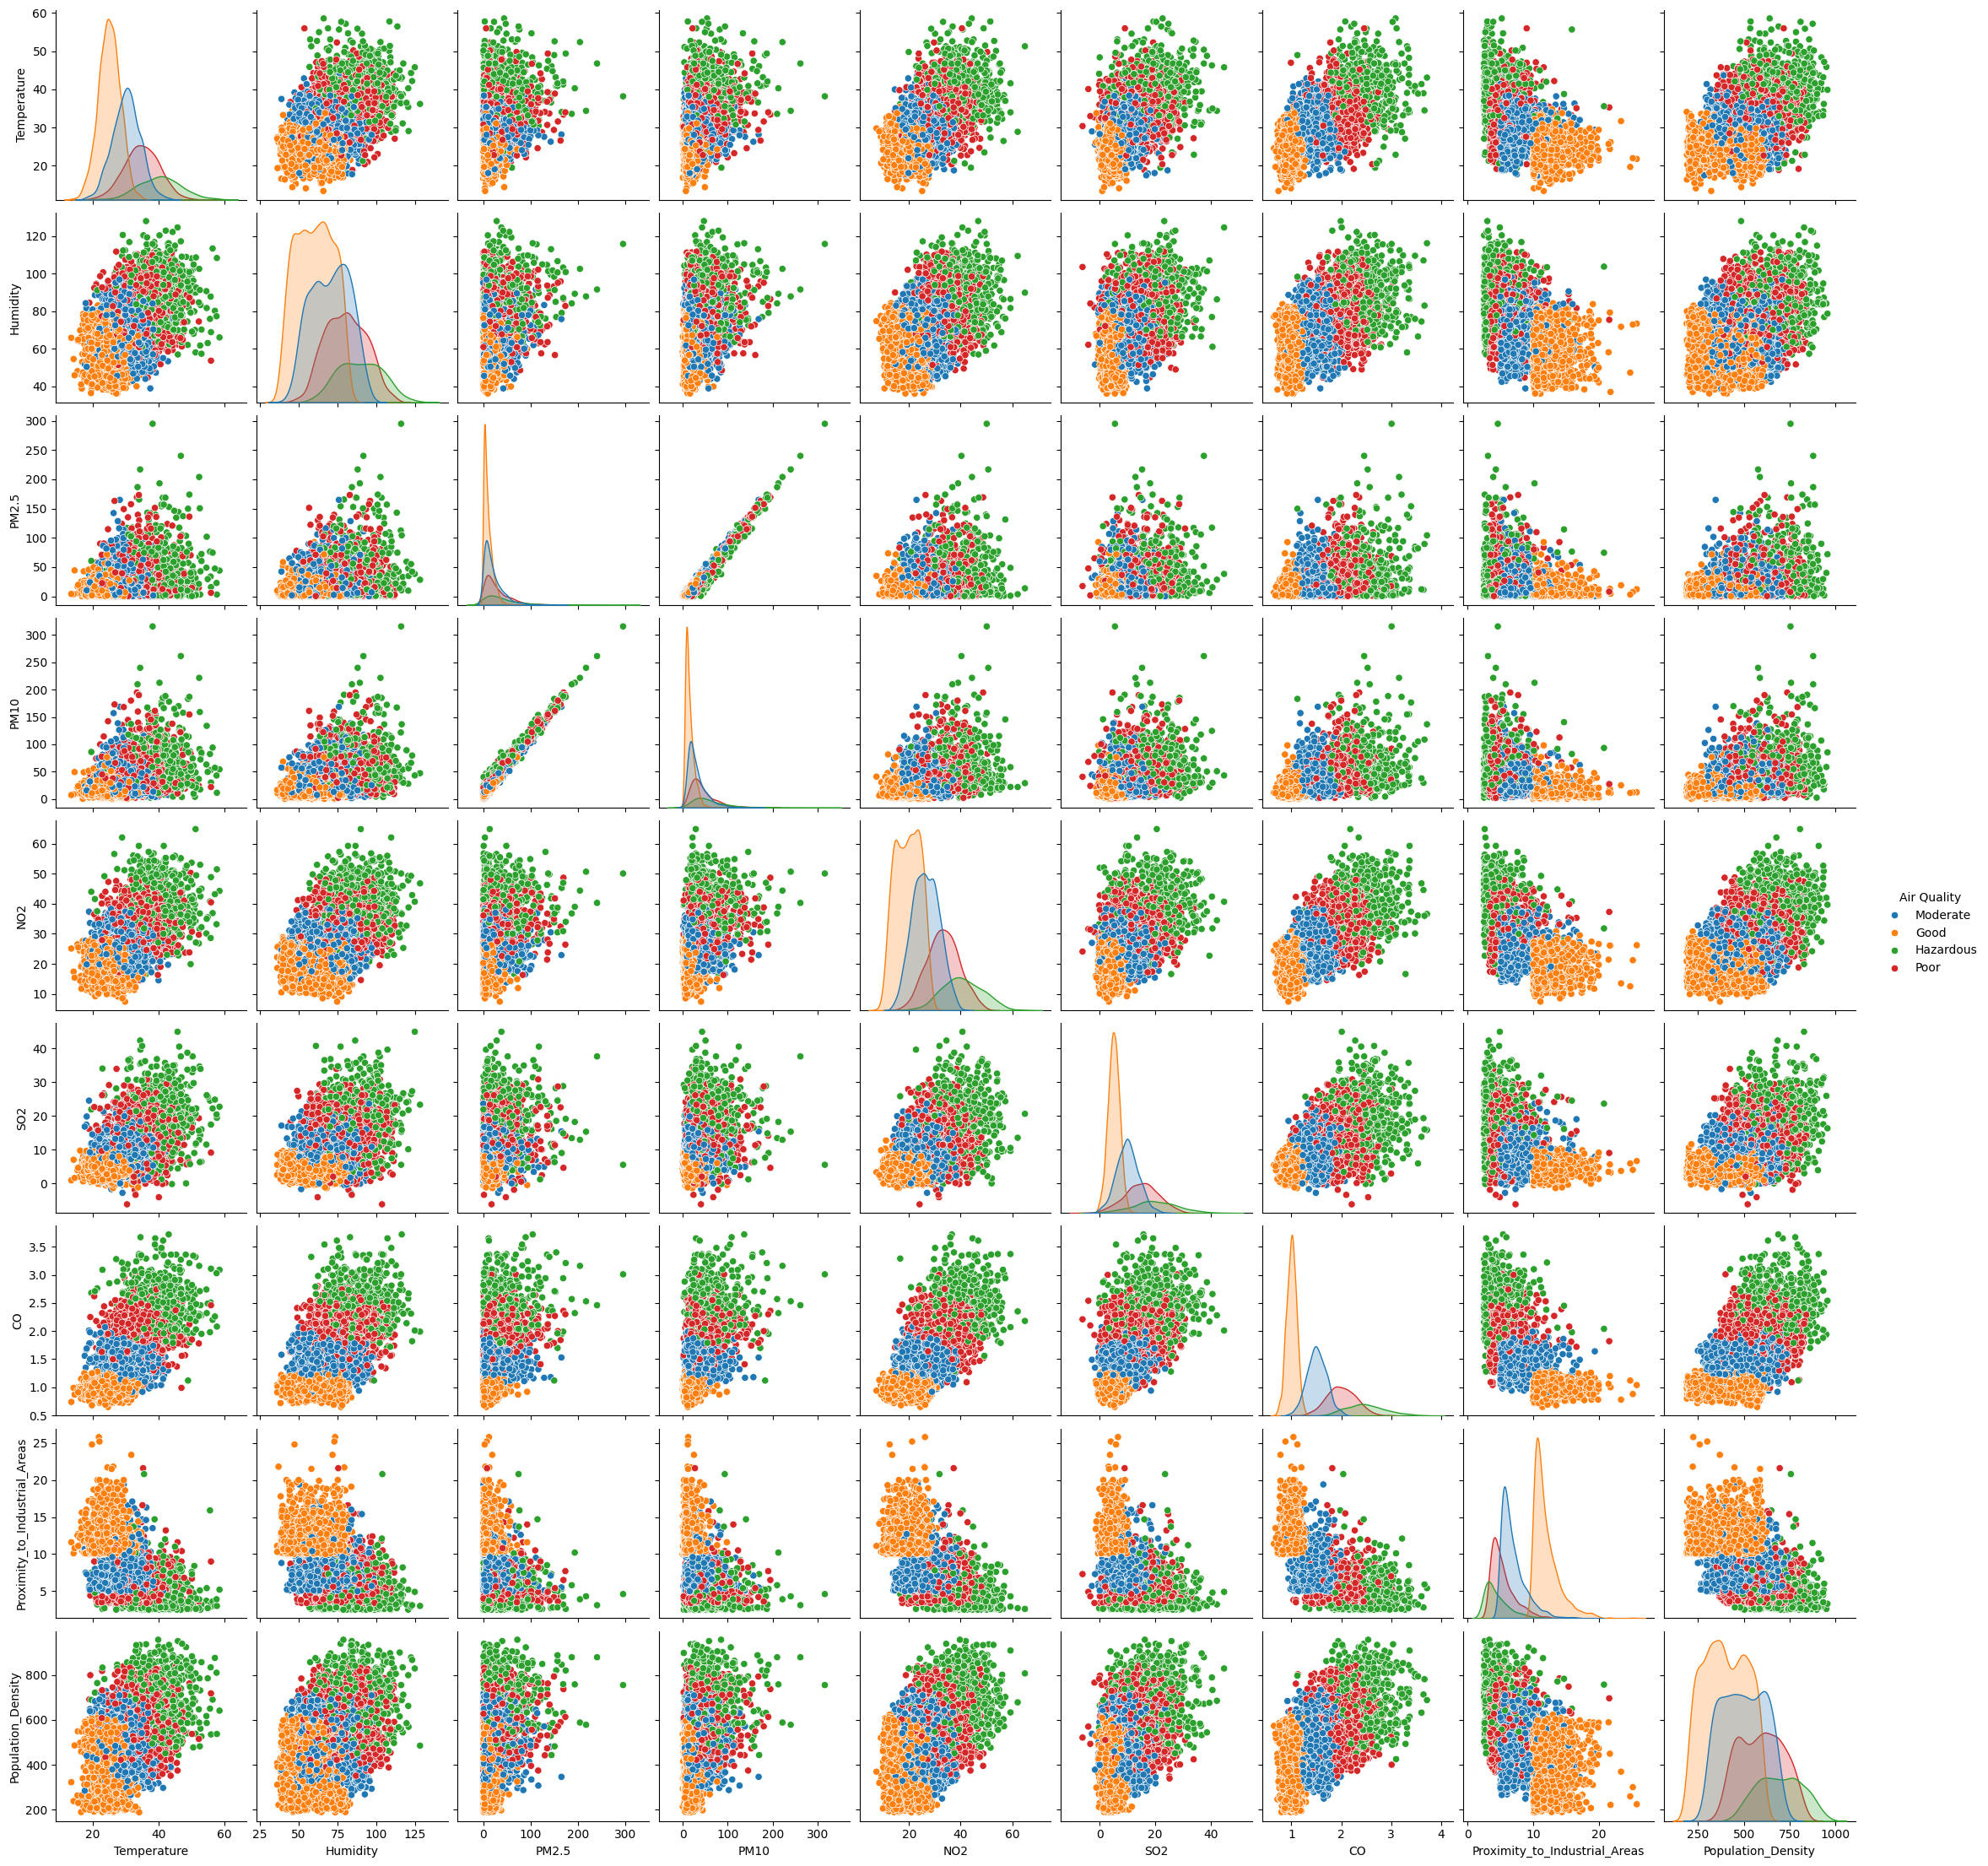

In [10]:
sns.pairplot(data=data,hue='Air Quality')

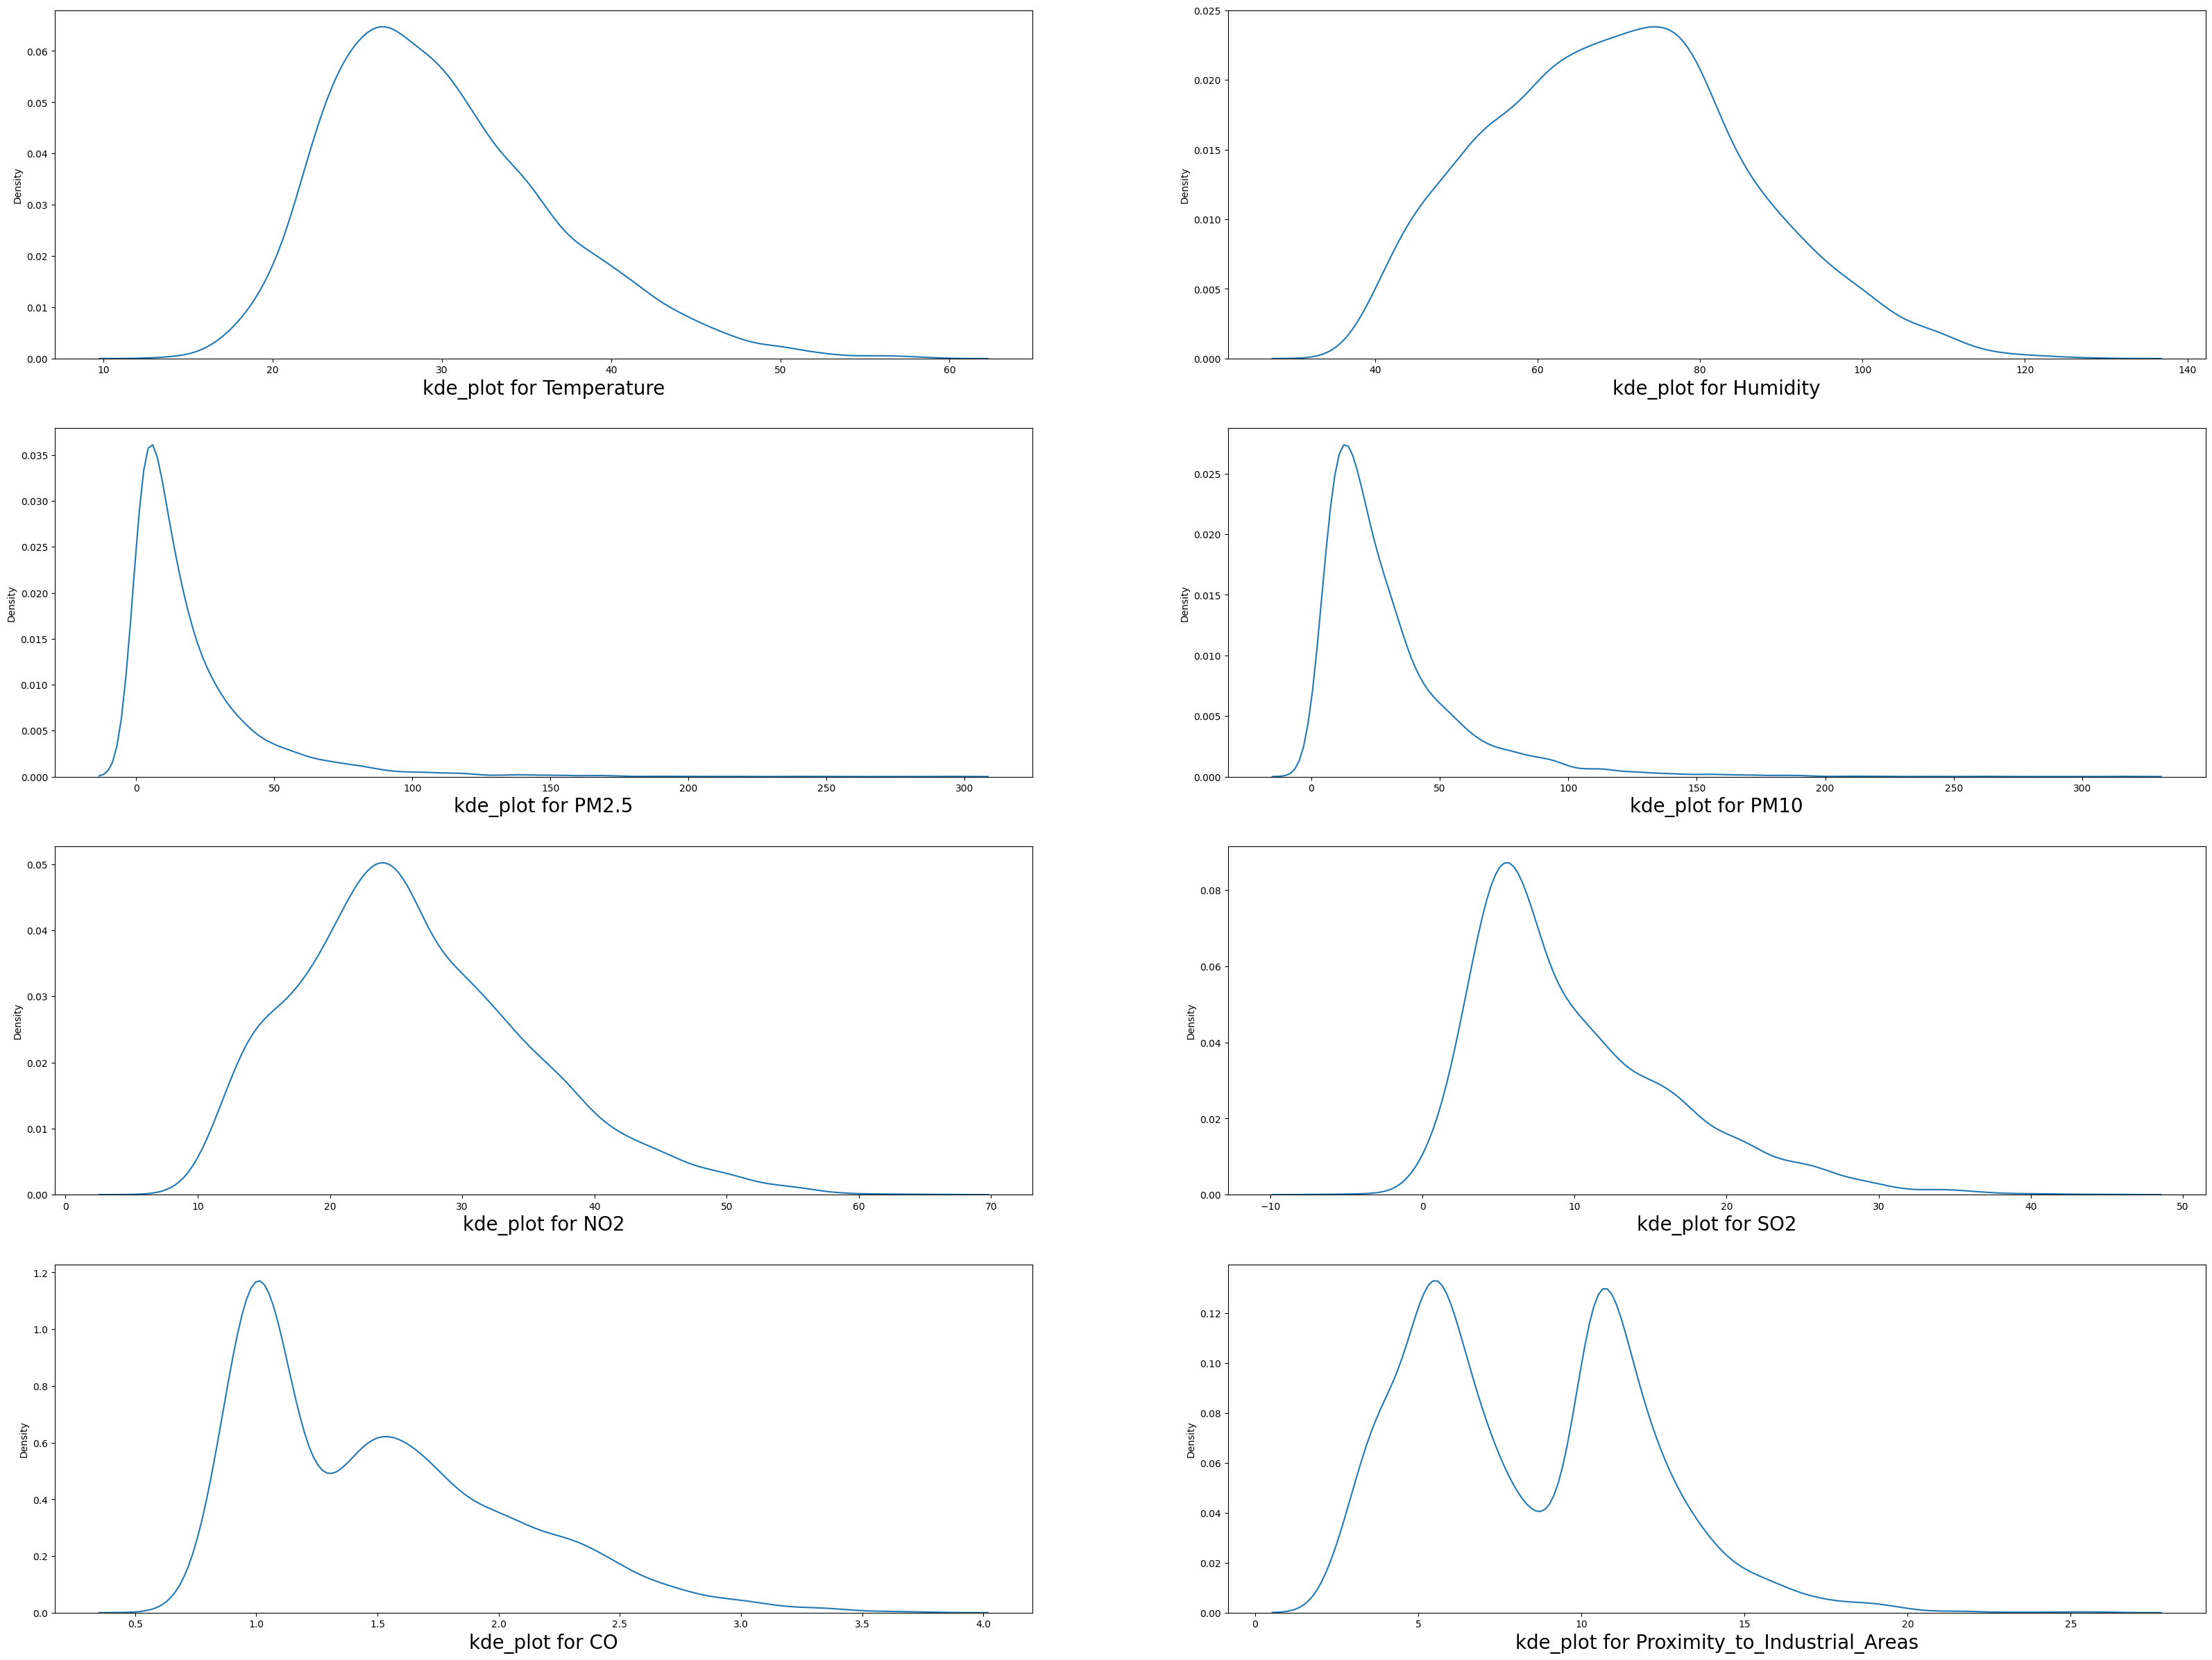

In [11]:
plt.figure(figsize=(40,30))
x=['Temperature','Humidity','PM2.5','PM10','NO2','SO2','CO','Proximity_to_Industrial_Areas']
for axis,i in enumerate(x,start=1):
    plt.subplot(4,2,axis)
    sns.kdeplot(data[i])
    plt.xlabel("kde_plot for "+f'{i}',fontdict={'fontsize':20})


plt.show()

<Axes: ylabel='count'>

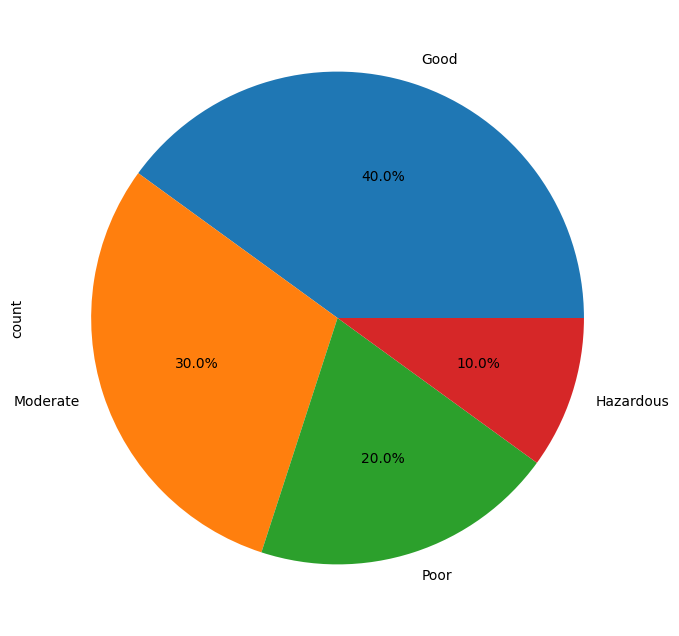

In [12]:
plt.figure(figsize=(10,8))
round(data['Air Quality'].value_counts()/5000*100,1).plot.pie(autopct = "%1.1f%%")

<Axes: xlabel='PM2.5', ylabel='PM10'>

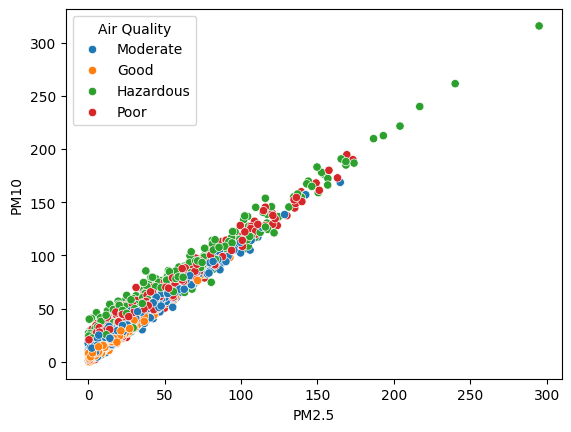

In [13]:
sns.scatterplot(data=data,x='PM2.5',y='PM10',hue='Air Quality')

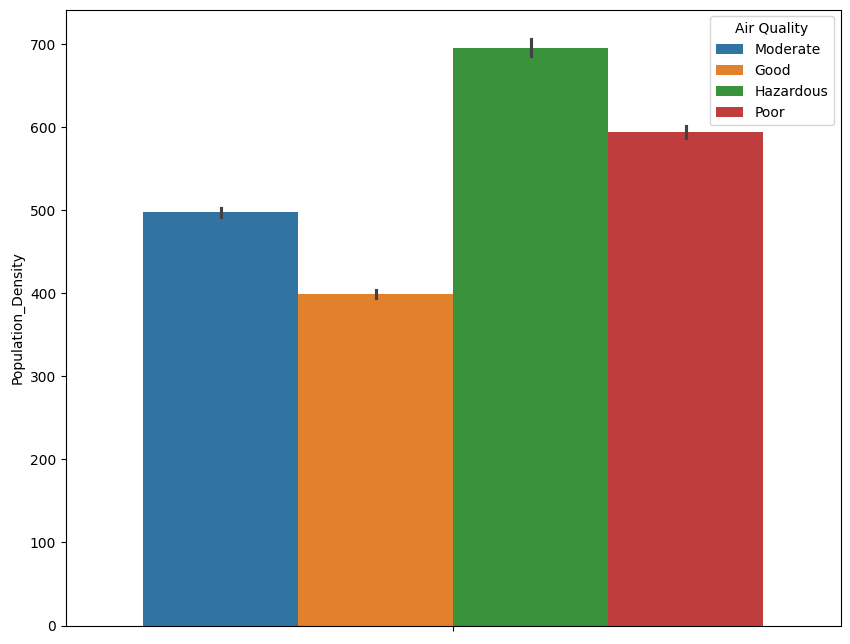

In [14]:
plt.figure(figsize=(10,8))
sns.barplot(data=data,y='Population_Density',hue='Air Quality')
plt.show()

# Data Preparation

In [16]:
X = data.drop(columns=["Air Quality"])
y = data["Air Quality"]

In [17]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [18]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [21]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(800, activation="relu"),
    layers.Dense(700, activation="relu"),
    layers.Dense(500, activation="relu"),
    layers.Dense(400, activation="relu"),
    layers.Dense(300, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [22]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 800)            │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 700)            │       560,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │       350,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 400)            │       200,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 300)            │       120,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,241,104 (4.73 MB)

 Trainable params: 1,241,104 (4.73 MB)

 Non-trainable params: 0 (0.00 B)

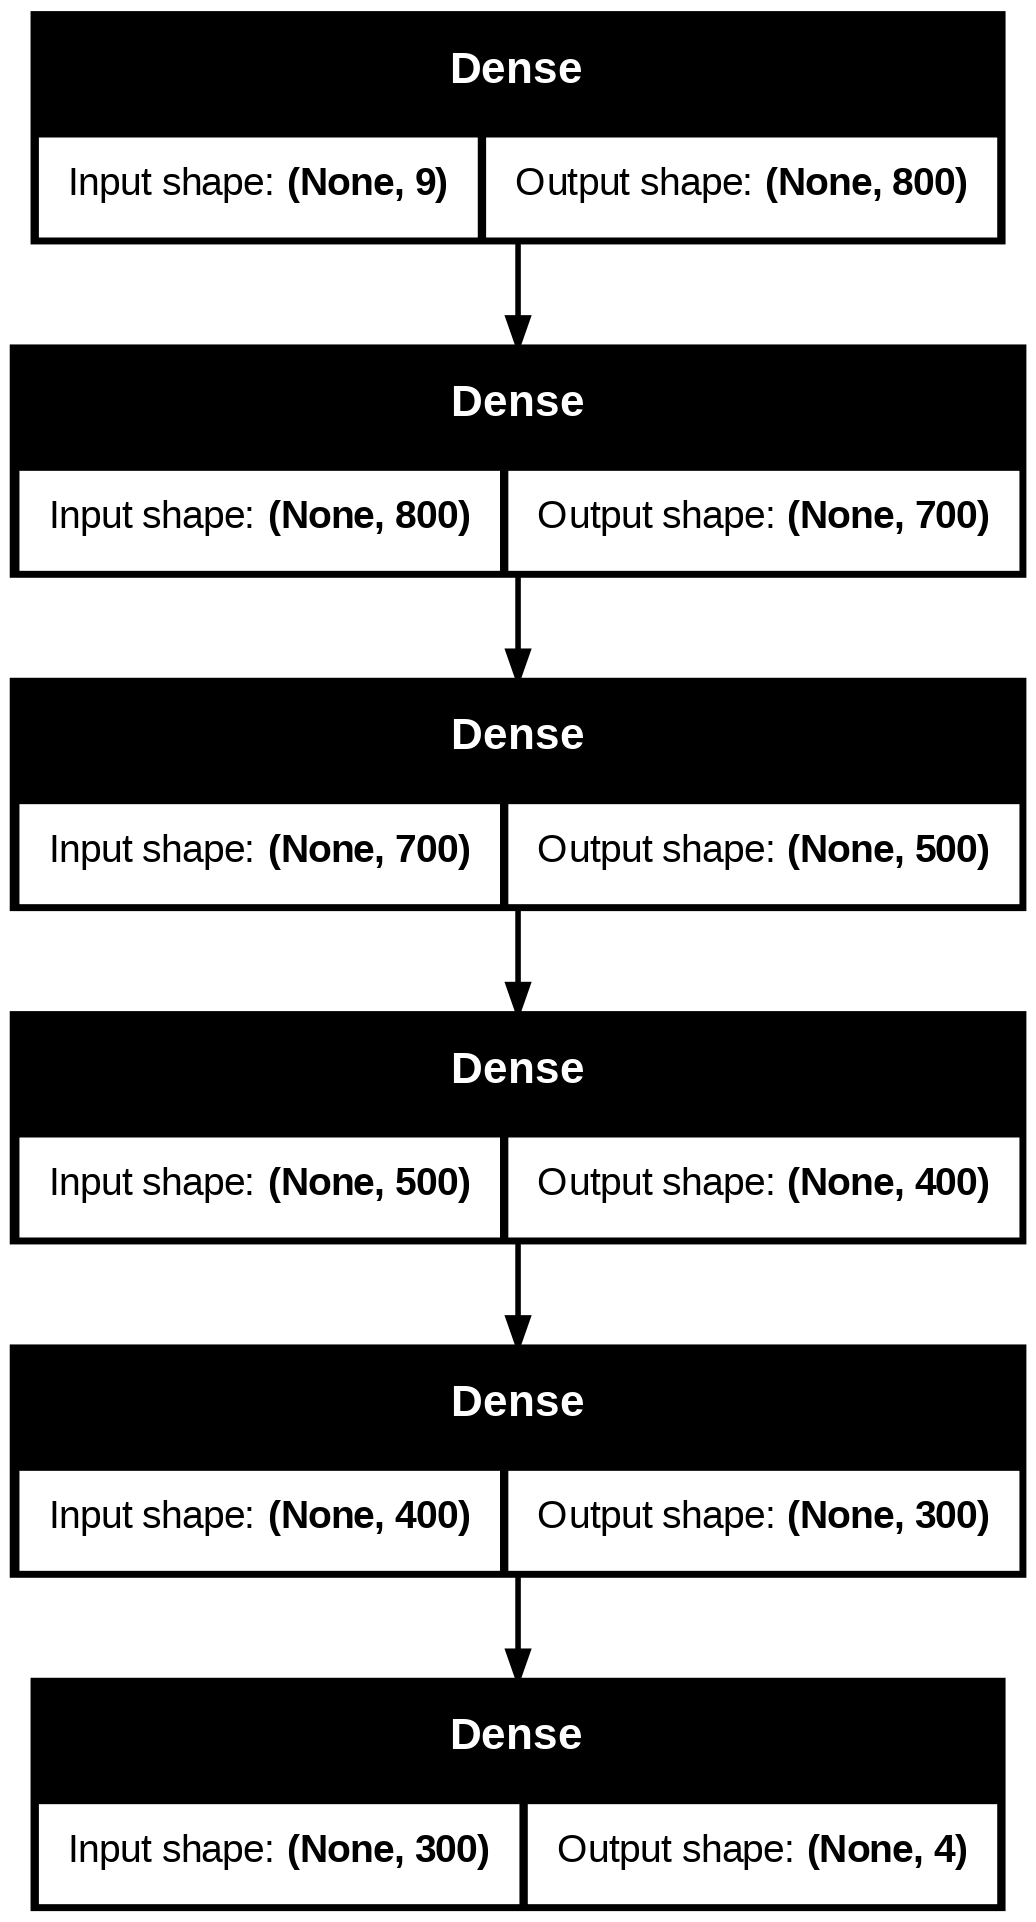

In [24]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [25]:
history = model.fit(X_train, y_train,
                    epochs=300,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/300
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7374 - loss: 0.6279 - val_accuracy: 0.8430 - val_loss: 0.3160
Epoch 2/300
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8815 - loss: 0.2864 - val_accuracy: 0.8910 - val_loss: 0.2575
Epoch 3/300
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9233 - loss: 0.1961 - val_accuracy: 0.8610 - val_loss: 0.2545
Epoch 4/300
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9241 - loss: 0.2014 - val_accuracy: 0.9230 - val_loss: 0.1915
Epoch 5/300
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9207 - loss: 0.2082 - val_accuracy: 0.9160 - val_loss: 0.1984
Epoch 6/300
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9297 - loss: 0.1893 - val_accuracy: 0.9340 - val_loss: 0.1608
Epoch 7/300
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9231 - loss: 0.1762 - val_accuracy: 0.9490 - val_loss: 0.1360
Epoch 8/300
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9392 - loss: 0.1587 - val_accu

# Evaluation

In [27]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9456 - loss: 0.2504
Akurasi Model: 0.9510
Loss Model: 0.3043


In [28]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

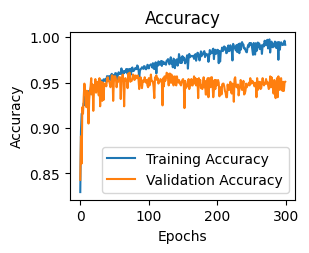

In [31]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

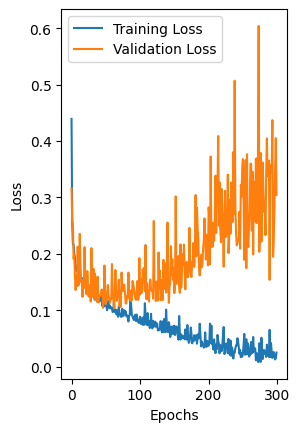

In [32]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


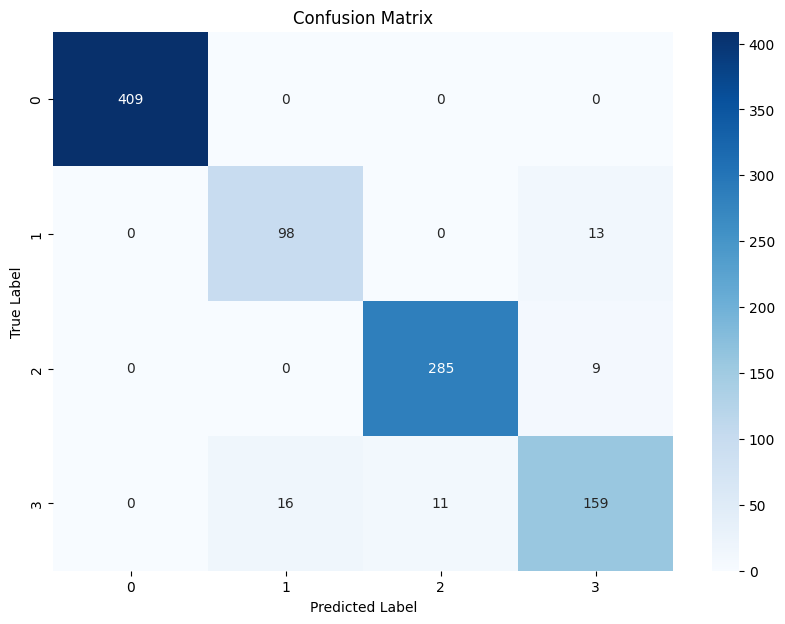

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       409
           1       0.86      0.88      0.87       111
           2       0.96      0.97      0.97       294
           3       0.88      0.85      0.87       186

    accuracy                           0.95      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.95      0.95      0.95      1000



In [33]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [52]:
sample_input = np.array([[1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619]])
sample_input_df = pd.DataFrame(sample_input)

In [53]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [54]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_air = le.inverse_transform([predicted_class])

print(f"Kualitas Udara: {predicted_air[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Kualitas Udara: Moderate


## Save Model

In [55]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('air-quality-and-pollution-assessment.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpsg_59bbr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137426011482128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137426011483088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137426011484624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137426011481168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137426011484816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137426011481744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137426011484048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137426011486160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137426011485584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137426011487888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137426011487696: TensorS

In [56]:
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']